# COE 311K Midterm Project: U.S. GDP Growth Rate Analysis Using Least Squares, Polynomial Fitting, and Cubic Spline

In [105]:
import numpy as np
import matplotlib.pyplot as plt

##GENERAL NOTE - when making code, one thing I have been trying to improve is being more organized.
# the usage of print seperators in the code is something I took from AI and implemented
# it is not a straight rip from the AI

## Section 1: Data

In [106]:
# values of "x" represent quarter indices
# 2010 Q1 = 1, 2010 Q2 = 2, ... 2023 Q4 = 56 etc.

x_data = np.array([
    1, 5, 9, 13, 17, 19, 22, 25, 27, 28,
    29, 33, 37, 41, 42, 43, 45, 49, 54, 56
], dtype=float)

y_data = np.array([
    1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
    1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3
], dtype=float)

# full quarter range
x_full = np.arange(1, 57, dtype=float)

## Section 2: Helper Functions

In [107]:
# functions in order to organize
# idea for print seperator function from AI

def print_separator(title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

## Section 3: Linear Least Squares

In [108]:
# model form: y = a0 + a1*x
# this is the simple least squares line

def linear_least_squares(x, y):
    n = len(x)

    # build A with columns [1, x]
    A = np.zeros((n, 2))
    for i in range(n):
        A[i, 0] = 1.0
        A[i, 1] = x[i]

    # normal equations
    ATA = A.T @ A
    ATy = A.T @ y

    coeffs = np.linalg.solve(ATA, ATy)
    return coeffs, A, ATA

def evaluate_line(coeffs, x):
    return coeffs[0] + coeffs[1] * x

## Section 4: Polynomial Fit

In [109]:
# model form: y = a0 + a1*x
# this is the simple least squares line

def build_vandermonde(x, degree):
    n = len(x)
    V = np.zeros((n, degree + 1))

    # each row is [1, x, x^2, ..., x^degree]
    for i in range(n):
        for j in range(degree + 1):
            V[i, j] = x[i] ** j

    return V

def polynomial_least_squares(x, y, degree):
    # build the Vandermonde matrix first
    V = build_vandermonde(x, degree)

    # normal equations for least squares polynomial fit
    VTV = V.T @ V
    VTy = V.T @ y

    coeffs = np.linalg.solve(VTV, VTy)
    return coeffs, V, VTV

def evaluate_polynomial(coeffs, x):
    y_pred = np.zeros_like(x, dtype=float)

    for j in range(len(coeffs)):
        y_pred += coeffs[j] * x ** j

    return y_pred

## Section 5: Natural Cubic Spline

In [110]:
# natural spline means the second derivatives at the two ends are 0
# this section builds the tridiagonal system for the spline

def setup_natural_spline_system(x, y):
    n = len(x)

    # interval widths
    h = np.zeros(n - 1)
    for i in range(n - 1):
        h[i] = x[i + 1] - x[i]

    # tridiagonal system for interior second derivatives
    lower = np.zeros(n - 2)
    diag = np.zeros(n - 2)
    upper = np.zeros(n - 2)
    rhs = np.zeros(n - 2)

    for i in range(1, n - 1):
        row = i - 1

        diag[row] = 2 * (h[i - 1] + h[i])
        if row > 0:
            lower[row] = h[i - 1]
        if row < n - 3:
            upper[row] = h[i]

        rhs[row] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

    return lower, diag, upper, rhs, h

def thomas_algorithm(lower, diag, upper, rhs):
    # solves a tridiagonal system efficiently
    n = len(diag)

    if n == 0:
        return np.array([])

    c_prime = np.zeros(n)
    d_prime = np.zeros(n)

    c_prime[0] = upper[0] / diag[0] if n > 1 else 0.0
    d_prime[0] = rhs[0] / diag[0]

    for i in range(1, n):
        denom = diag[i] - lower[i] * c_prime[i - 1]
        c_prime[i] = upper[i] / denom if i < n - 1 else 0.0
        d_prime[i] = (rhs[i] - lower[i] * d_prime[i - 1]) / denom

    x_sol = np.zeros(n)
    x_sol[-1] = d_prime[-1]

    for i in range(n - 2, -1, -1):
        x_sol[i] = d_prime[i] - c_prime[i] * x_sol[i + 1]

    return x_sol

def natural_cubic_spline_coefficients(x, y):
    lower, diag, upper, rhs, h = setup_natural_spline_system(x, y)

    # solve for interior second derivatives only
    M_interior = thomas_algorithm(lower, diag, upper, rhs)

    # add natural boundary conditions
    M = np.zeros(len(x))
    if len(x) > 2:
        M[1:-1] = M_interior

    return M, h, lower, diag, upper, rhs

def evaluate_spline(x, y, M, x_eval):
    y_eval = np.zeros_like(x_eval, dtype=float)

    for k in range(len(x_eval)):
        xe = x_eval[k]

        # find the interval containing xe
        if xe <= x[0]:
            i = 0
        elif xe >= x[-1]:
            i = len(x) - 2
        else:
            i = np.searchsorted(x, xe) - 1
        h = x[i + 1] - x[i]

        term1 = M[i] * (x[i + 1] - xe) ** 3 / (6 * h)
        term2 = M[i + 1] * (xe - x[i]) ** 3 / (6 * h)
        term3 = (y[i] - M[i] * h ** 2 / 6) * (x[i + 1] - xe) / h
        term4 = (y[i + 1] - M[i + 1] * h ** 2 / 6) * (xe - x[i]) / h

        y_eval[k] = term1 + term2 + term3 + term4

    return y_eval

def spline_first_derivative_piece(x, y, M, i, xe):
    h = x[i + 1] - x[i]

    term1 = -M[i] * (x[i + 1] - xe) ** 2 / (2 * h)
    term2 = M[i + 1] * (xe - x[i]) ** 2 / (2 * h)
    term3 = -(y[i] - M[i] * h ** 2 / 6) / h
    term4 = (y[i + 1] - M[i + 1] * h ** 2 / 6) / h

    return term1 + term2 + term3 + term4

def spline_second_derivative_piece(x, M, i, xe):
    h = x[i + 1] - x[i]
    return M[i] * (x[i + 1] - xe) / h + M[i + 1] * (xe - x[i]) / h

## Section 6: Checking Continuity

In [111]:
# the instructions say to verify C0, C1, and C2 continuity by checking from both sides of interior knots
# so that is what this function does

def check_spline_continuity(x, y, M):
    print_separator("PART A.1 - C0, C1, C2 CONTINUITY CHECKS")

    eps = 1e-8

    for i in range(1, len(x) - 1):
        xk = x[i]

        # I used AI to verify the two derivatives, as I was unsure on the approach to ensure continuity
        # The labeled parts C0, C1, and C2 are made with the assistance of AI
        # C0
        left_val = evaluate_spline(x, y, M, np.array([xk - eps]))[0]
        right_val = evaluate_spline(x, y, M, np.array([xk + eps]))[0]

        # C1
        left_d1 = spline_first_derivative_piece(x, y, M, i - 1, xk - eps)
        right_d1 = spline_first_derivative_piece(x, y, M, i, xk + eps)

        # C2
        left_d2 = spline_second_derivative_piece(x, M, i - 1, xk - eps)
        right_d2 = spline_second_derivative_piece(x, M, i, xk + eps)

        print("Interior knot x =", xk)
        print("C0 left value  =", left_val)
        print("C0 right value =", right_val)
        print("C0 difference  =", abs(left_val - right_val))
        print()

        print("C1 left derivative  =", left_d1)
        print("C1 right derivative =", right_d1)
        print("C1 difference       =", abs(left_d1 - right_d1))
        print()

        print("C2 left derivative  =", left_d2)
        print("C2 right derivative =", right_d2)
        print("C2 difference       =", abs(left_d2 - right_d2))
        print("-" * 50)

    print("Natural boundary conditions:")
    print("M[0]  =", M[0])
    print("M[-1] =", M[-1])

## Section 7: Plotting

In [112]:
# spline plot
# im making the plots as functions so all printed results from the code will be shown at the end when executed
def plot_spline(x, y, x_dense, y_spline_dense):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label="Data points")
    plt.plot(x_dense, y_spline_dense, label="Natural cubic spline")
    plt.title("Part A - Natural Cubic Spline Interpolation")
    plt.xlabel("Quarter index")
    plt.ylabel("GDP growth (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

# spline plot with full quarters
def plot_spline_full_quarters(x, y, x_full, y_full):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label="Given data points")
    plt.plot(x_full, y_full, label="Spline evaluated at every quarter")
    plt.title("Spline Evaluation at Every Quarter from 2010 Q1 to 2023 Q4")
    plt.xlabel("Quarter index")
    plt.ylabel("GDP growth (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

# polynomial plot versus spline
def plot_poly_vs_spline(x, y, x_dense, y_poly_dense, y_spline_dense):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label="Data points")
    plt.plot(x_dense, y_poly_dense, label="Degree 4 polynomial fit")
    plt.plot(x_dense, y_spline_dense, label="Natural cubic spline")
    plt.title("Part B.1 - Degree 4 Polynomial Fit vs Cubic Spline")
    plt.xlabel("Quarter index")
    plt.ylabel("GDP growth (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

# linear squares fit plot
def plot_linear_fit(x, y, x_dense, y_line_dense):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label="Data excluding COVID quarters")
    plt.plot(x_dense, y_line_dense, label="Least squares linear model")
    plt.title("Part B.2 - Linear Least Squares Fit Excluding COVID Quarters")
    plt.xlabel("Quarter index")
    plt.ylabel("GDP growth (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

# the residuals plot
def plot_residuals(x, residuals, title):
    plt.figure(figsize=(10, 5))
    plt.axhline(0)
    plt.scatter(x, residuals)
    plt.title(title)
    plt.xlabel("Quarter index")
    plt.ylabel("Residual")
    plt.grid(True)
    plt.show()

## Section 8: Part A

In [113]:
# cubic spline interpolation
def part_a(x, y, x_full):
    print_separator("PART A - NATURAL CUBIC SPLINE")

    n = len(x)
    M, h, lower, diag, upper, rhs = natural_cubic_spline_coefficients(x, y)

    print("Number of data points n =", n)
    print("Number of spline intervals =", n - 1)
    print("Number of unknown interior second derivatives =", n - 2)
    print()
    print("h values:")
    print(h)
    print()
    print("Lower diagonal:")
    print(lower)
    print("Main diagonal:")
    print(diag)
    print("Upper diagonal:")
    print(upper)
    print("Right-hand side:")
    print(rhs)
    print()
    print("Solved second derivative values M:")
    print(M)

    # checking interpolation at original data points
    y_at_data = evaluate_spline(x, y, M, x)

    print_separator("PART A - CHECK SPLINE HITS GIVEN DATA")
    for i in range(len(x)):
        print("x =", x[i], "actual y =", y[i], "spline y =", y_at_data[i], "difference =", abs(y[i] - y_at_data[i]))

    # evaluating at every quarter in the full range
    y_full = evaluate_spline(x, y, M, x_full)

    print_separator("PART A - SPLINE VALUES AT EVERY QUARTER")
    for i in range(len(x_full)):
        print("Quarter index", int(x_full[i]), "spline value =", y_full[i])

    # continuity checks
    check_spline_continuity(x, y, M)

    # smooth curve for plotting, also ensuring continuity
    x_dense = np.linspace(x[0], x[-1], 600)
    y_spline_dense = evaluate_spline(x, y, M, x_dense)

    plot_spline(x, y, x_dense, y_spline_dense)
    plot_spline_full_quarters(x, y, x_full, y_full)

    return M, x_dense, y_spline_dense, y_full

## Section 9: Part B.1

In [114]:
# comparing polynomial and least squares
def part_b1(x, y, x_dense, y_spline_dense):
    print_separator("PART B.1 - DEGREE 4 POLYNOMIAL FIT")

    degree = 4

    # compute polynomial coefficients using least squares
    # this uses the Vandermonde matrix + normal equations
    coeffs, V, VTV = polynomial_least_squares(x, y, degree)

    # evaluate polynomial at original data points
    # used to compute error metrics
    y_poly_data = evaluate_polynomial(coeffs, x)

    # evaluate polynomial on dense grid for plotting
    y_poly_dense = evaluate_polynomial(coeffs, x_dense)

    # compute fit quality metrics
    poly_rmse = rmse(y, y_poly_data)
    poly_r2 = r_squared(y, y_poly_data)

    # condition number tells us how stable the system is
    poly_cond = np.linalg.cond(VTV)

    print("Degree =", degree)
    print("Polynomial coefficients:")
    for i in range(len(coeffs)):
        print("a" + str(i), "=", coeffs[i])

    print()
    print("Condition number of V^T V =", poly_cond)
    print("RMSE =", poly_rmse)
    print("R^2 =", poly_r2)

    # residuals = actual - predicted
    residuals_poly = y - y_poly_data

    print_separator("PART B.1 - FIT VALUES AND RESIDUALS")
    for i in range(len(x)):
        print("x =", x[i],
              "actual =", y[i],
              "predicted =", y_poly_data[i],
              "residual =", residuals_poly[i])

    # plot polynomial vs spline for comparison
    plot_poly_vs_spline(x, y, x_dense, y_poly_dense, y_spline_dense)

    # plot residuals to see error behavior
    plot_residuals(x, residuals_poly, "Residual Plot - Degree 4 Polynomial Fit")

    return coeffs, y_poly_data

## Section 10: Part B.2

In [115]:
def part_b2(x, y):
    print_separator("PART B.2 - LINEAR LEAST SQUARES EXCLUDING COVID QUARTERS")

    # remove COVID quarters (41 to 45)
    # these are extreme outliers and will distort the linear fit
    mask = (x < 41) | (x > 45)

    x_no_covid = x[mask]
    y_no_covid = y[mask]

    # compute linear least squares fit (y = a0 + a1 x)
    coeffs, A, ATA = linear_least_squares(x_no_covid, y_no_covid)

    # evaluate line at data points
    y_line_data = evaluate_line(coeffs, x_no_covid)

    # compute error metrics
    line_rmse = rmse(y_no_covid, y_line_data)
    line_r2 = r_squared(y_no_covid, y_line_data)

    # check conditioning of normal equations
    line_cond = np.linalg.cond(ATA)

    # residuals show how far predictions are from actual values
    residuals_line = y_no_covid - y_line_data

    print("Intercept =", coeffs[0])
    print("Slope =", coeffs[1])
    print()
    print("Condition number of A^T A =", line_cond)
    print("RMSE =", line_rmse)
    print("R^2 =", line_r2)

    print_separator("PART B.2 - FIT VALUES AND RESIDUALS")
    for i in range(len(x_no_covid)):
        print("x =", x_no_covid[i],
              "actual =", y_no_covid[i],
              "predicted =", y_line_data[i],
              "residual =", residuals_line[i])

    # create smooth line for plotting
    x_dense = np.linspace(np.min(x_no_covid), np.max(x_no_covid), 300)
    y_line_dense = evaluate_line(coeffs, x_dense)

    # plot linear fit
    plot_linear_fit(x_no_covid, y_no_covid, x_dense, y_line_dense)

    # plot residuals
    plot_residuals(x_no_covid, residuals_line, "Residual Plot - Linear Least Squares Fit")

    return coeffs

## Section 11: Run Main


PROJECT OUTPUT

PART A - NATURAL CUBIC SPLINE
Number of data points n = 20
Number of spline intervals = 19
Number of unknown interior second derivatives = 18

h values:
[4. 4. 4. 4. 2. 3. 3. 2. 1. 1. 4. 4. 4. 1. 1. 2. 4. 5. 2.]

Lower diagonal:
[0. 4. 4. 4. 2. 3. 3. 2. 1. 1. 4. 4. 4. 1. 1. 2. 4. 5.]
Main diagonal:
[16. 16. 16. 12. 10. 12. 10.  6.  4. 10. 16. 16. 10.  4.  6. 12. 18. 14.]
Upper diagonal:
[4. 4. 4. 2. 3. 3. 2. 1. 1. 4. 4. 4. 1. 1. 2. 4. 5. 0.]
Right-hand side:
[   5.7    -2.7    -2.1    11.4   -13.9     1.      9.    -16.2     7.2
    4.8    -0.9   -13.2  -125.7   509.4  -453.9    70.65   16.65   -2.1 ]

Solved second derivative values M:
[ 0.00000000e+00  3.95919853e-01 -1.58679413e-01 -4.36202203e-01
  1.37848822e+00 -1.69852494e+00  1.09424311e-01  1.59416103e+00
 -3.63494160e+00  2.42132754e+00  1.14963145e+00 -2.27941050e+00
  7.74301054e+00 -3.19926317e+01  1.63254275e+02 -1.11624467e+02
  2.62962632e+01 -5.41405611e+00  1.78359147e+00  0.00000000e+00]

PART A - CH

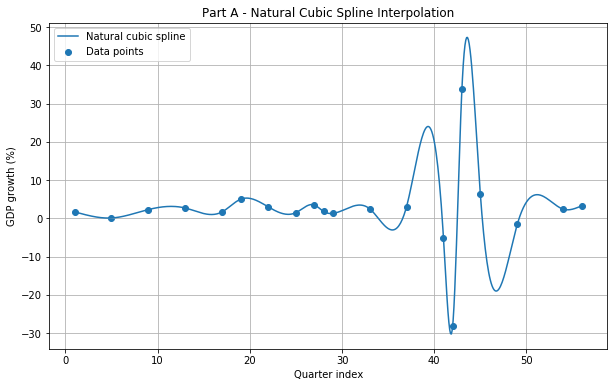

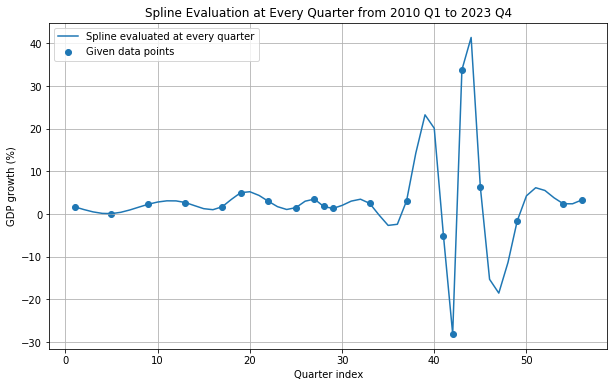


PART B.1 - DEGREE 4 POLYNOMIAL FIT
Degree = 4
Polynomial coefficients:
a0 = 0.2114033395848678
a1 = 0.4127332084867474
a2 = -0.021103692068389673
a3 = 0.00035789227648335206
a4 = -1.7106009509653148e-06

Condition number of V^T V = 331159708504818.56
RMSE = 10.031440678677116
R^2 = 0.0035410151185396588

PART B.1 - FIT VALUES AND RESIDUALS
x = 1.0 actual = 1.7 predicted = 0.6033890376787578 residual = 1.096610962321242
x = 5.0 actual = 0.1 predicted = 1.7911444892749282 residual = -1.691144489274928
x = 9.0 actual = 2.3 predicted = 2.4662833751431106 residual = -0.16628337514311076
x = 13.0 actual = 2.7 predicted = 2.7478439480281325 residual = -0.0478439480281323
x = 17.0 actual = 1.7 predicted = 2.744354528432092 residual = -1.0443545284320919
x = 19.0 actual = 5.0 predicted = 2.6667573620129574 residual = 2.3332426379870426
x = 22.0 actual = 3.0 predicted = 2.4874653888181104 residual = 0.5125346111818896
x = 25.0 actual = 1.5 predicted = 2.2637893325915552 residual = -0.7637893325

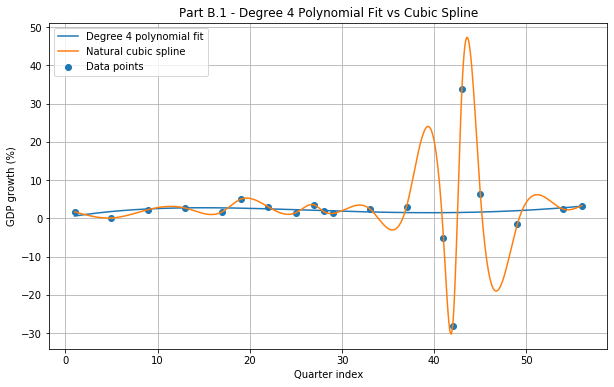

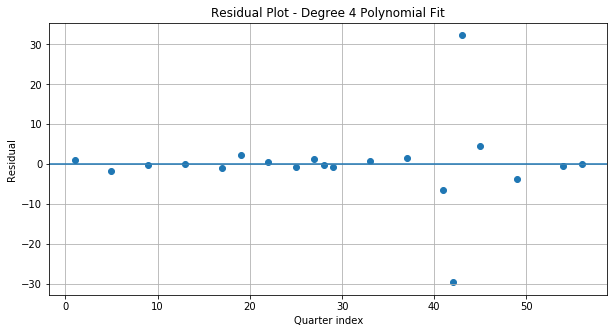


PART B.2 - LINEAR LEAST SQUARES EXCLUDING COVID QUARTERS
Intercept = 2.194285187007874
Slope = -0.0019069881889763796

Condition number of A^T A = 3605.5885513928274
RMSE = 1.4431864883291987
R^2 = 0.00044329440682566723

PART B.2 - FIT VALUES AND RESIDUALS
x = 1.0 actual = 1.7 predicted = 2.1923781988188975 residual = -0.49237819881889755
x = 5.0 actual = 0.1 predicted = 2.184750246062992 residual = -2.084750246062992
x = 9.0 actual = 2.3 predicted = 2.1771222933070864 residual = 0.12287770669291342
x = 13.0 actual = 2.7 predicted = 2.169494340551181 residual = 0.5305056594488193
x = 17.0 actual = 1.7 predicted = 2.1618663877952753 residual = -0.46186638779527533
x = 19.0 actual = 5.0 predicted = 2.1580524114173225 residual = 2.8419475885826775
x = 22.0 actual = 3.0 predicted = 2.1523314468503933 residual = 0.8476685531496067
x = 25.0 actual = 1.5 predicted = 2.1466104822834646 residual = -0.6466104822834646
x = 27.0 actual = 3.5 predicted = 2.142796505905512 residual = 1.35720349409

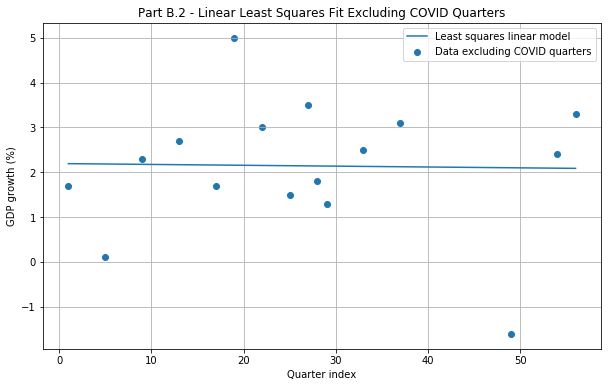

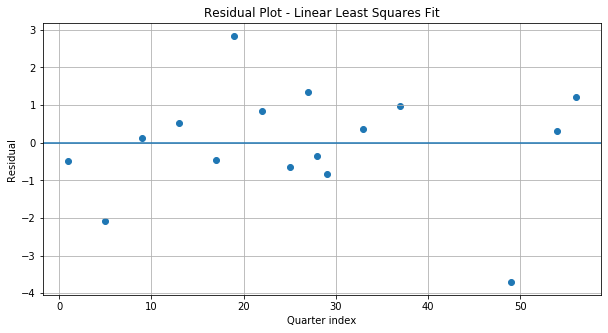

In [116]:
def main():
    print_separator("PROJECT OUTPUT")

    M, x_dense, y_spline_dense, y_full = part_a(x_data, y_data, x_full)
    poly_coeffs, y_poly_data = part_b1(x_data, y_data, x_dense, y_spline_dense)
    line_coeffs = part_b2(x_data, y_data)

main()

# Write Up

## Introduction
In this project, I analyzed U.S. GDP growth data using several numerical methods, including natural cubic splines, polynomial least squares, and linear least squares. The goal was to model the data and compare how well each method represents the overall trend, especially in the presence of large fluctuations like those seen during the COVID-19 period. For the spline, I focused on interpolation and smoothness, while for the least squares models, I focused on approximation and error analysis using RMSE and R² values. By comparing these different approaches, I was able to evaluate which method provides the most accurate and reliable representation of the data.

## Part A
   For this part, I used a natural cubic spline to interpolate the GDP growth data. The idea behind a spline is that instead of using one big equation, you break it into smaller cubic polynomials between each pair of points, and then make sure they connect smoothly. To keep everything smooth, the spline has to satisfy three conditions at every interior point: the function values match, the first derivatives match, and the second derivatives match. These are referred to as C⁰, C¹, and C² continuity. I also used natural boundary conditions, which just means the second derivatives at the endpoints are set to zero.
   
   To build the spline, I computed the interval widths and set up a tridiagonal system based on those continuity conditions. Then I solved that system using the Thomas algorithm, which is designed for this kind of matrix and is pretty efficient. After solving it, I obtained the second derivative values "M", which are then used to construct each cubic piece of the spline.
   
   To check that everything was working, I evaluated the spline at all the original data points. The spline values matched the actual data values almost exactly, which confirms that it is interpolating correctly. I also checked continuity by evaluating the spline and its first and second derivatives just to the left and right of each interior knot. The differences were essentially zero, so that confirms the spline satisfies C⁰, C¹, and C² continuity.
   
   When plotted, the spline gives a smooth curve that follows the data very closely. It handles sharp changes in GDP growth, especially during the COVID period, without causing weird oscillations in other parts of the graph. I also evaluated the spline at every quarter in the full range, which gives reasonable estimates even where no original data was provided.

## Part B
In this part, I applied least squares methods to fit both a degree-4 polynomial and a linear model to the GDP data. For the polynomial model, I manually constructed the Vandermonde matrix, where each row contains powers of the input value up to degree 4, and then used the normal equations to solve for the coefficients. This approach minimizes the squared error between the predicted values and the actual data. After computing the coefficients, I evaluated the polynomial at both the original data points and a dense set of points for plotting. To measure how well the model fits the data, I calculated the RMSE and R² values. The RMSE came out to 10.0314, which is fairly large, and the R² value was 0.00354, which is extremely close to zero. This basically shows that the polynomial isn’t doing a good job capturing the variation in the data. The residual plot also shows that the errors are not evenly distributed, and the model struggles especially with the sharp changes in GDP during the COVID period. This makes sense since a single global polynomial has trouble adapting to local fluctuations in the data.

For the linear model, I first removed the COVID quarters since those values are extreme outliers and would heavily affect the fit. Using the remaining data, I fit a line of the form y = a0 + a1x (where 0 and 1 are subscripts) using the normal equations. The resulting model produced an RMSE of 1.4432 and an R² value of 0.000443. While the RMSE is smaller than the polynomial fit, the R² value is still basically zero, meaning the model does not explain much of the variation in the data. The residual plot shows that the errors are more evenly spread out compared to the polynomial, but the model is too simple to capture the ups and downs in GDP growth.

Comparing the two models, the polynomial has a much larger RMSE and uneven residuals, while the linear model has a smaller RMSE but still fails to explain the data due to its simplicity. Neither model performs particularly well overall, but for different reasons. The polynomial is too unstable and sensitive to extreme values, while the linear model is too simple to capture the behavior of the data. This comparison helps explain why a spline, which adapts locally and maintains smoothness, is a better choice for this dataset.

## Part C
Based on all the results, the natural cubic spline is the best model for this dataset. The spline passes exactly through all the data points and stays smooth by matching both the first and second derivatives at each interior point. It also adjusts locally, which lets it handle sudden changes in the data without messing up the rest of the curve.

In comparison, the degree-4 polynomial has a large RMSE of 10.0314 and an R² value that is basically zero, so it doesn’t fit the data well. The linear model has a smaller RMSE of 1.4432, but its R² value is still near zero and it can’t capture the variability in the data. Overall, the spline gives the most accurate and reliable representation of GDP growth, proving that it's the best choice.

## Part C Addendum - Big O
Big O notation describes how the runtime of an algorithm grows as the size of the input increases. In this project, the linear least squares model has a time complexity of O(n) because building the matrices and solving the small system scales directly with the number of data points. The degree-4 polynomial fit involves building a Vandermonde matrix and solving the normal equations, which has complexity O(n d² + d³). Since the degree is fixed at 4, this basically behaves like O(n) for this problem. The natural cubic spline also has a complexity of O(n), since setting up the tridiagonal system and solving it with the Thomas algorithm both scale linearly with the number of points.

The Big O analysis doesn’t really change the recommendation. All three methods are efficient for this dataset, but the spline still gives the best accuracy and smoothness with an insignificant amount of extra time being spent, due to it being so small.

## Conclusion
Overall, the results show that the natural cubic spline provides the best representation of the GDP data. It passes exactly through all the data points and remains smooth by satisfying continuity conditions, which makes it well-suited for capturing both general trends and local fluctuations. The polynomial and linear least squares models, on the other hand, both struggle in different ways. The polynomial fit has a large error and is sensitive to extreme values, while the linear model is too simple to capture the variability in the data, even after removing outliers. Although all of the methods are computationally efficient, the spline clearly performs better in terms of accuracy and behavior. Based on both the visual results and the quantitative metrics, it is the most appropriate choice for modeling this dataset.